In [195]:
import numpy as np
import pandas as pd
import statistics
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [196]:
tb=pd.read_csv('/content/Zomato Dataset.csv')

Data Information gathering & Cleaning

In [197]:
tb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  object 
 1   Delivery_person_ID           45584 non-null  object 
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  object 
 9   Time_Orderd                  43853 non-null  object 
 10  Time_Order_picked            45584 non-null  object 
 11  Weather_conditions           44968 non-null  object 
 12  Road_traffic_density         44983 non-null  object 
 13  Vehicle_conditio

In [198]:
tb.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken (min),Unnamed: 20
count,43730.000000,43676.000000,45584.000000,45584.000000,45584.000000,45584.000000,45584.000000,44591.000000,45584.000000,0.0
mean,29.566911,4.633774,17.017948,70.229684,17.465480,70.844161,1.023385,0.744635,26.293963,NaN
std,5.815064,0.334744,8.185674,22.885575,7.335562,21.120578,0.839055,0.572510,9.384298,NaN
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,0.000000,0.000000,10.000000,NaN
25%,25.000000,4.500000,12.933284,73.170000,12.988453,73.280000,0.000000,0.000000,19.000000,NaN
50%,30.000000,4.700000,18.551440,75.897963,18.633934,76.002574,1.000000,1.000000,26.000000,NaN
75%,35.000000,4.900000,22.728163,78.044095,22.785049,78.107044,2.000000,1.000000,32.000000,NaN
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000,NaN


In [199]:
tb.isnull().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,1854
Delivery_person_Ratings,1908
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,1731


In [200]:
tb = tb.drop(columns=['Unnamed: 20'])

In [201]:
# Renaming the column
tb.rename(columns=  {'Time_taken (min)': 'Time_taken'},inplace=True)

In [202]:
# Droping the rows where Time ordered data is not available
tb = tb.dropna(subset=['Time_Orderd'])

In [203]:
tb['Delivery_person_Age'] = tb['Delivery_person_Age'].fillna(tb['Delivery_person_Age'].median())
tb['Delivery_person_Ratings'] = tb['Delivery_person_Ratings'].fillna(tb['Delivery_person_Ratings'].median())
tb['multiple_deliveries'] = tb['multiple_deliveries'].fillna(tb['multiple_deliveries'].median())

In [204]:
tb['Weather_conditions'] = tb['Weather_conditions'].fillna('Unknown')
tb['Road_traffic_density'] = tb['Road_traffic_density'].fillna('Unknown')
tb['Festival'] = tb['Festival'].fillna('No')
tb['City'] = tb['City'].fillna('Unknown')

In [205]:
tb.isnull().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,0


Distance Formula: Haversine with given delivery & Restraunt lat lon given

In [206]:


def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [207]:
tb['distance_km'] = haversine(
    tb['Restaurant_latitude'],
    tb['Restaurant_longitude'],
    tb['Delivery_location_latitude'],
    tb['Delivery_location_longitude']
)

Average Velocity distribution across different city types

Urban_velocity: 1.2687141152362698
Metropolitian_velocity: 0.9757750710359661
Semi-urban_velocity: 0.2615800465754786


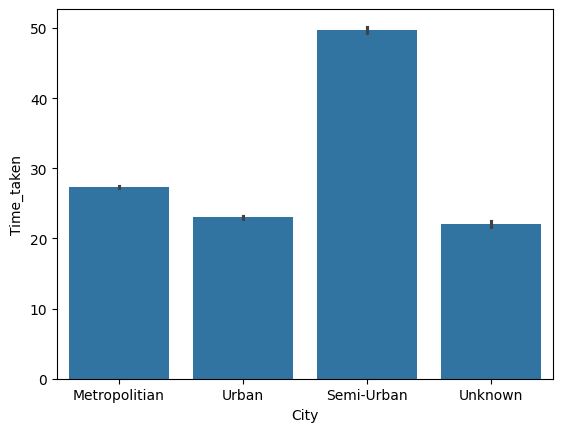

In [208]:
sns.barplot(data=tb,x="City",y="Time_taken")
print(f"Urban_velocity: {np.mean(tb['distance_km'][tb['City']=='Urban']) / np.mean(tb['Time_taken'][tb['City']=='Urban'])}")

print(f"Metropolitian_velocity: {np.mean(tb['distance_km'][tb['City']=='Metropolitian']) / np.mean(tb['Time_taken'][tb['City']=='Metropolitian'])}")

print(f"Semi-urban_velocity: {np.mean(tb['distance_km'][tb['City']=='Semi-Urban']) / np.mean(tb['Time_taken'][tb['City']=='Semi-Urban'])}")


The time taken In Semi-Urban area is the highest: Checking for possible reasons.

In [209]:
# Hypothising the reason of slow deliveries in Semi_urban areas
#road_condition=tb['Road_traffic_density'][tb['City']=='Semi-Urban']
#sns.barplot(road_condition)
tb.groupby('City')[['distance_km', 'Time_taken']].mean()
# Distance wise Semi-Urban is the one with the least distance but with the highest time among others

,distance_km,Time_taken
City,,
Metropolitian,26.647056,27.308605
Semi-Urban,13.010254,49.737179
Unknown,27.087808,22.078671
Urban,29.179514,22.999283


Interesting observation: The distance_km is least in S-Urban despite that the time taken is almost twice than the other reason

In [210]:
tb.groupby(['City', 'Road_traffic_density'])['Time_taken'].median()
#Higher average time for Semi-urban city under all road_traffic_density

City           Road_traffic_density
Metropolitian  High                    28.0
               Jam                     32.0
               Low                     22.0
               Medium                  27.0
Semi-Urban     High                    49.0
               Jam                     49.0
               Medium                  48.0
Unknown        High                    22.0
               Jam                     25.0
               Low                     18.0
               Medium                  23.0
Urban          High                    24.0
               Jam                     27.0
               Low                     18.0
               Medium                  23.0
Name: Time_taken, dtype: float64

Irrespective of traffic condition- The delivery time is higher in all case

In [211]:
tb.groupby(['City', 'multiple_deliveries'])['Time_taken'].mean()
#Semi-urban delivery time is high (~50 min) regardless of batching.

City           multiple_deliveries
Metropolitian  0.0                    24.085324
               1.0                    27.519241
               2.0                    40.395206
               3.0                    47.390335
Semi-Urban     0.0                    49.086957
               1.0                    49.698630
               2.0                    48.727273
               3.0                    50.789474
Unknown        0.0                    18.853428
               1.0                    23.252907
               2.0                    38.034483
               3.0                    45.500000
Urban          0.0                    19.781394
               1.0                    24.032441
               2.0                    40.177686
               3.0                    48.156250
Name: Time_taken, dtype: float64

In [212]:
tb.groupby(['City', 'Type_of_vehicle'])['Time_taken'].agg(['median','count'])

median  count
City          Type_of_vehicle                
Metropolitian electric_scooter    25.0   2632
              motorcycle          27.0  19446
              scooter             25.0  10718
Semi-Urban    electric_scooter    49.0      3
              motorcycle          49.0    143
              scooter             48.0     10
Unknown       electric_scooter    19.5     88
              motorcycle          22.0    609
              scooter             19.0    447
Urban         electric_scooter    20.0    811
              motorcycle          23.0   5429
              scooter             19.0   3517

## The above Analysis is Void becasue the result is statistically insignificant

No impact of batching on the delivery in Semi-Urban

In [213]:
tb.groupby('City')['distance_km'].mean()

,distance_km
City,
Metropolitian,26.647056
Semi-Urban,13.010254
Unknown,27.087808
Urban,29.179514


Interesting to note here- Distance within Semi-urban is half compared to Metropolitian & Urban. Though the time taken is highest; Indicating operational inefficiency

<Axes: xlabel='City', ylabel='Count'>

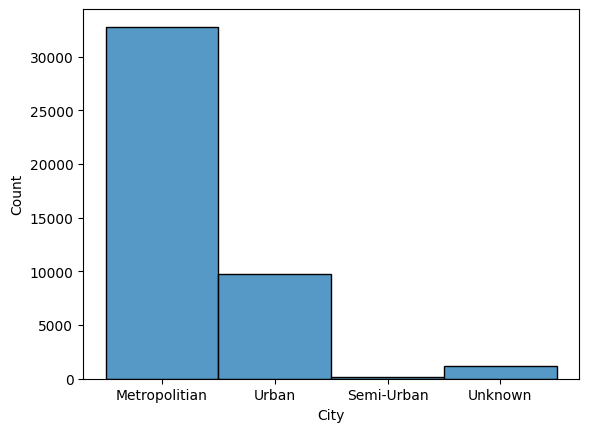

In [214]:
sns.histplot(data=tb,x="City")
# Count of delivery-partners are least in Semi-urban areas leading to

Funnel
1. Order Placed
2. Pickup
3. Transit
4. Delivery

In [215]:
# What is the trend for wait time across city

In [216]:
tb['order_time'] = pd.to_datetime(tb['Time_Orderd'], errors='coerce')
tb['pickup_time'] = pd.to_datetime(tb['Time_Order_picked'], errors='coerce')

tb['wait_time'] = (tb['pickup_time'] - tb['order_time']).dt.total_seconds() / 60

/tmp/ipykernel_2359/2622479913.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tb['order_time'] = pd.to_datetime(tb['Time_Orderd'], errors='coerce')
/tmp/ipykernel_2359/2622479913.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tb['pickup_time'] = pd.to_datetime(tb['Time_Order_picked'], errors='coerce')


<Axes: xlabel='wait_time', ylabel='Count'>

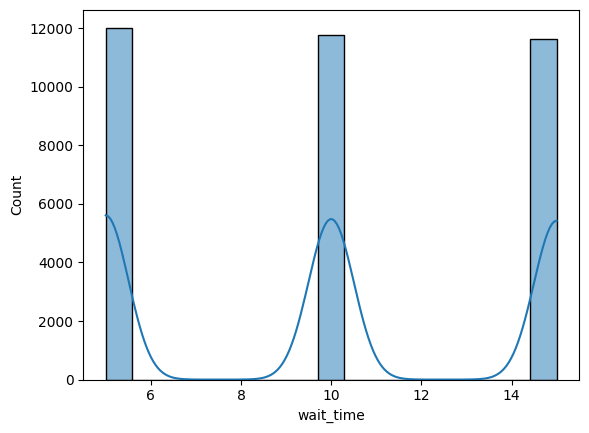

In [264]:
sns.histplot(tb['wait_time'],kde=1)

In [217]:
tb.groupby('City')['wait_time'].mean()
# Not a drastic high waiting time in case of Semi-Urban areas

,wait_time
City,
Metropolitian,9.940323
Semi-Urban,10.220588
Unknown,9.989130
Urban,9.950476


In [218]:
# Do the wait time impacted by the weather condition, Vehcile type, road traffic?
tb.groupby('Weather_conditions')['wait_time'].mean()
#Inference: weather_condition don't have any impact on wait_time
tb.groupby('Type_of_vehicle')['wait_time'].mean()

,wait_time
Type_of_vehicle,
electric_scooter,9.942247
motorcycle,9.954705
scooter,9.928372


In [219]:
tb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43853 entries, 0 to 45583
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           43853 non-null  object        
 1   Delivery_person_ID           43853 non-null  object        
 2   Delivery_person_Age          43853 non-null  float64       
 3   Delivery_person_Ratings      43853 non-null  float64       
 4   Restaurant_latitude          43853 non-null  float64       
 5   Restaurant_longitude         43853 non-null  float64       
 6   Delivery_location_latitude   43853 non-null  float64       
 7   Delivery_location_longitude  43853 non-null  float64       
 8   Order_Date                   43853 non-null  object        
 9   Time_Orderd                  43853 non-null  object        
 10  Time_Order_picked            43853 non-null  object        
 11  Weather_conditions           43853 non-null  o

This is a interesting finding: Earlier the inference was going to the direction that there is higher waiting time in semi-urban area due to shortage of delivery partner (but this is not the case). Something is happening within transit of delivery

What could be the potential reasons?
1. Indirect route casuing higher distance travelled?
2. Poor roads condition?
3. Poor weather conditions?

In [220]:
tb.groupby('City')['multiple_deliveries'].mean()
# Indicates average multiple deliveries were higher in Semi-urban

,multiple_deliveries
City,
Metropolitian,0.771192
Semi-Urban,1.480769
Unknown,0.662587
Urban,0.675515


In [221]:
tb['time_per_km'] = tb['Time_taken'] / tb['distance_km']
tb.groupby('City')['time_per_km'].mean()

,time_per_km
City,
Metropolitian,4.238108
Semi-Urban,4.965695
Unknown,3.831873
Urban,4.099430


In [222]:
tb.groupby('City')['Vehicle_condition'].mean()
# Vehicle comditions not too much good comparitively with Urban & Metro

,Vehicle_condition
City,
Metropolitian,0.981614
Semi-Urban,0.217949
Unknown,1.078671
Urban,1.069181


In [223]:
tb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43853 entries, 0 to 45583
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           43853 non-null  object        
 1   Delivery_person_ID           43853 non-null  object        
 2   Delivery_person_Age          43853 non-null  float64       
 3   Delivery_person_Ratings      43853 non-null  float64       
 4   Restaurant_latitude          43853 non-null  float64       
 5   Restaurant_longitude         43853 non-null  float64       
 6   Delivery_location_latitude   43853 non-null  float64       
 7   Delivery_location_longitude  43853 non-null  float64       
 8   Order_Date                   43853 non-null  object        
 9   Time_Orderd                  43853 non-null  object        
 10  Time_Order_picked            43853 non-null  object        
 11  Weather_conditions           43853 non-null  o

In [224]:
tb[tb['City']=='Semi-Urban'].groupby('Weather_conditions')['City'].count()

,City
Weather_conditions,
Cloudy,44
Fog,31
Sandstorms,20
Stormy,20
Sunny,19
Windy,22


In [225]:
tb[tb['City']=='Semi-Urban']['time_per_km'].describe()

,time_per_km
count,156.000000
mean,4.965695
std,4.065137
min,2.299083
25%,2.869161
50%,3.866082
75%,4.884522
max,32.463737


In [226]:
outliers_semiurban=tb[(tb['City'] == 'Semi-Urban') & (tb['time_per_km'] > 10)]
outliers_semiurban.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken,distance_km,order_time,pickup_time,wait_time,time_per_km
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.0,13.000000,13.000000,13.000000,12,12,11.000000,13.000000
mean,29.846154,4.192308,20.235594,78.615562,20.260209,78.640178,0.0,1.307692,48.769231,3.751700,2026-04-21 16:46:15.000000256,2026-04-21 17:48:20,12.272727,15.191182
min,20.000000,3.500000,10.994136,72.790489,11.014136,72.820489,0.0,0.000000,46.000000,1.509376,2026-04-21 11:10:00,2026-04-21 11:25:00,5.000000,10.085585
25%,24.000000,3.800000,19.109300,73.169083,19.139300,73.199083,0.0,1.000000,47.000000,3.025086,2026-04-21 11:33:45,2026-04-21 11:40:00,10.000000,10.292379
50%,28.000000,4.200000,22.310329,76.642620,22.340329,76.672620,0.0,1.000000,48.000000,4.528165,2026-04-21 19:17:30,2026-04-21 20:00:00,15.000000,11.002881
75%,36.000000,4.500000,23.359033,85.325347,23.371058,85.337872,0.0,2.000000,50.000000,4.560965,2026-04-21 20:51:15,2026-04-21 21:16:15,15.000000,16.859023
max,39.000000,4.900000,23.374989,85.335486,23.404989,85.365486,0.0,3.000000,53.000000,4.663645,2026-04-21 21:55:00,2026-04-21 22:10:00,15.000000,32.463737
std,6.718707,0.497429,4.459868,5.687972,4.458210,5.683702,0.0,1.031553,2.420532,1.188613,NaN,NaN,4.100998,7.718979


<Axes: xlabel='City', ylabel='time_per_km'>

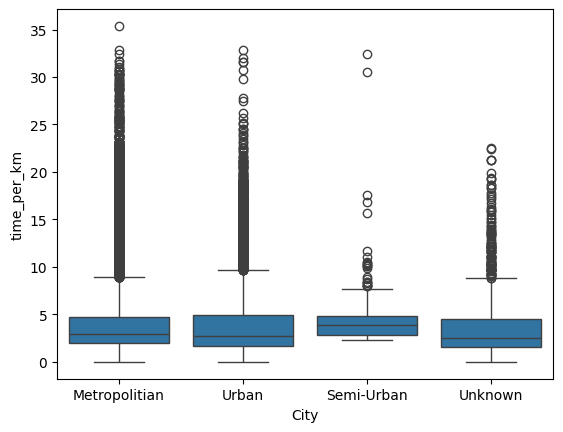

In [227]:
sns.boxplot(x='City', y='time_per_km', data=tb)

In [228]:
tb.groupby(['City', 'Weather_conditions'])['Time_taken'].mean()
# No impact of weather as well as it is consistently higher in all the cases

City           Weather_conditions
Metropolitian  Cloudy                29.936378
               Fog                   30.031619
               Sandstorms            26.896329
               Stormy                26.678481
               Sunny                 22.748798
               Windy                 26.946984
Semi-Urban     Cloudy                49.454545
               Fog                   49.193548
               Sandstorms            50.200000
               Stormy                49.600000
               Sunny                 50.263158
               Windy                 50.318182
Unknown        Cloudy                24.740964
               Fog                   23.521472
               Sandstorms            22.432692
               Stormy                21.658031
               Sunny                 18.759259
               Windy                 22.318182
Urban          Cloudy                25.060040
               Fog                   24.940328
               Sandstorms            22.699083
               Stormy                23.315631
               Sunny                 19.521277
               Windy                 23.291480
Name: Time_taken, dtype: float64

In [229]:
tb.groupby(['City', 'Weather_conditions'])['time_per_km'].mean()

City           Weather_conditions
Metropolitian  Cloudy                4.227065
               Fog                   4.247589
               Sandstorms            4.390604
               Stormy                4.417274
               Sunny                 3.673045
               Windy                 4.422912
Semi-Urban     Cloudy                3.235581
               Fog                   3.472826
               Sandstorms            7.531088
               Stormy                4.614079
               Sunny                 9.403791
               Windy                 4.684086
Unknown        Cloudy                4.518360
               Fog                   4.245476
               Sandstorms            3.824182
               Stormy                3.475115
               Sunny                 3.240249
               Windy                 3.917077
Urban          Cloudy                4.517770
               Fog                   4.320688
               Sandstorms            4.151767
               Stormy                4.266766
               Sunny                 3.527608
               Windy                 3.937782
Name: time_per_km, dtype: float64

In [230]:
tb.groupby(['City', 'Weather_conditions']).size()
# Can't make reliable prediction based on weather as the sample size is small for semi-urban comapritaively

City           Weather_conditions
Metropolitian  Cloudy                5627
               Fog                   5756
               Sandstorms            5421
               Stormy                5530
               Sunny                 4992
               Windy                 5470
Semi-Urban     Cloudy                  44
               Fog                     31
               Sandstorms              20
               Stormy                  20
               Sunny                   19
               Windy                   22
Unknown        Cloudy                 166
               Fog                    163
               Sandstorms             208
               Stormy                 193
               Sunny                  216
               Windy                  198
Urban          Cloudy                1499
               Fog                   1525
               Sandstorms            1635
               Stormy                1657
               Sunny                 1880
               Windy                 1561
dtype: int64

In [231]:
tb.groupby('City')['Delivery_person_Ratings'].mean()

,Delivery_person_Ratings
City,
Metropolitian,4.624744
Semi-Urban,4.497436
Unknown,4.666346
Urban,4.671036


In [232]:
tb.groupby('City')['time_per_km'].std()

,time_per_km
City,
Metropolitian,3.933870
Semi-Urban,4.065137
Unknown,3.589920
Urban,3.808666


In [233]:
#Alternate Hypo: Type of vehicle that is getting used and their condition is not so good

tb.groupby('City')['Type_of_vehicle'].value_counts(normalize=True)

City           Type_of_vehicle 
Metropolitian  motorcycle          0.592938
               scooter             0.326808
               electric_scooter    0.080254
Semi-Urban     motorcycle          0.916667
               scooter             0.064103
               electric_scooter    0.019231
Unknown        motorcycle          0.532343
               scooter             0.390734
               electric_scooter    0.076923
Urban          motorcycle          0.556421
               scooter             0.360459
               electric_scooter    0.083120
Name: proportion, dtype: float64

In [234]:
tb.groupby(['City', 'Type_of_vehicle'])['Time_taken'].mean()

City           Type_of_vehicle 
Metropolitian  electric_scooter    25.370061
               motorcycle          28.491721
               scooter             25.638085
Semi-Urban     electric_scooter    49.000000
               motorcycle          49.916084
               scooter             47.400000
Unknown        electric_scooter    21.522727
               motorcycle          23.226601
               scooter             20.624161
Urban          electric_scooter    21.504316
               motorcycle          24.313502
               scooter             21.315326
Name: Time_taken, dtype: float64

In [235]:
tb.groupby(['City', 'Vehicle_condition'])['Time_taken'].mean()

City           Vehicle_condition
Metropolitian  0                    30.612940
               1                    25.568428
               2                    25.532165
Semi-Urban     0                    50.082707
               1                    47.416667
               2                    48.090909
Unknown        0                    26.103125
               1                    20.545894
               2                    20.485366
Urban          0                    27.226860
               1                    21.164894
               2                    21.513994
Name: Time_taken, dtype: float64

Vehicle Condition/type is not the core reason for the delay as the time taken in all the vehicle condition is higher than other city types.[link text


Operational Inefficiency within Sub-Urban areas causing higher order delivery time overall.


<Axes: xlabel='Type_of_vehicle', ylabel='Time_taken'>

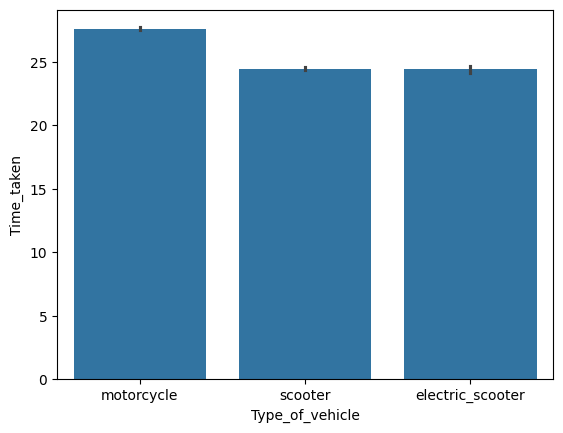

In [236]:
sns.barplot(data=tb,x="Type_of_vehicle",y="Time_taken")

<Axes: xlabel='City', ylabel='Time_taken'>

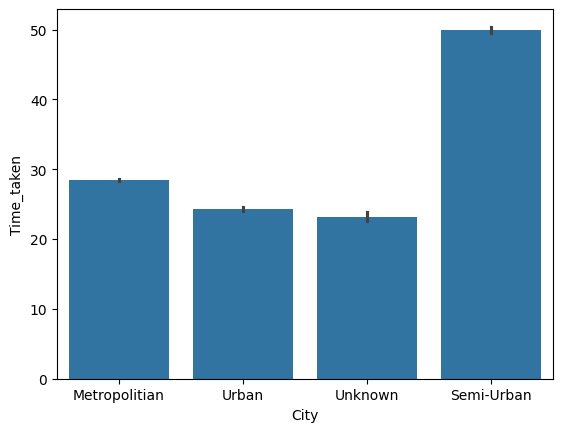

In [237]:
sns.barplot(data=tb[tb['Type_of_vehicle']=='motorcycle'],x="City",y="Time_taken")


**Reasoning**:
To identify columns with missing values and calculate their percentages, I will use `isnull().sum()` and then divide by the total number of rows. This will help in prioritizing cleaning efforts.



In [238]:
missing_values = tb.isnull().sum()
percentage_missing = (missing_values / len(tb)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage': percentage_missing
})

# Filter to show only columns with missing values
missing_info = missing_info[missing_info['Missing Count'] > 0]

print("Missing Values Information:")
print(missing_info.sort_values(by='Percentage', ascending=False))

Missing Values Information:
             Missing Count  Percentage
wait_time             8446   19.259800
pickup_time           4808   10.963902
order_time            4068    9.276446


In [239]:
numerical_columns = tb.select_dtypes(include=np.number)
if 'Unnamed: 20' in numerical_columns.columns:
    numerical_columns = numerical_columns.drop('Unnamed: 20', axis=1)

correlation_matrix = numerical_columns.corr()
print("Correlation Matrix:\n")
print(correlation_matrix)

Correlation Matrix:

                             Delivery_person_Age  Delivery_person_Ratings  \
Delivery_person_Age                     1.000000                -0.117448   
Delivery_person_Ratings                -0.117448                 1.000000   
Restaurant_latitude                     0.001408                -0.012124   
Restaurant_longitude                    0.000090                -0.013485   
Delivery_location_latitude              0.002449                -0.013478   
Delivery_location_longitude             0.000088                -0.013672   
Vehicle_condition                      -0.001906                 0.048850   
multiple_deliveries                     0.115187                -0.123712   
Time_taken                              0.303061                -0.359751   
distance_km                             0.002605                -0.002578   
wait_time                              -0.007390                 0.004971   
time_per_km                             0.119192       

**Reasoning**:
Now that the correlation matrix is calculated, I will visualize it using a heatmap to easily identify and interpret the relationships between numerical features. The heatmap will include annotations and a color bar for better readability, and the figure size will be adjusted for optimal presentation.



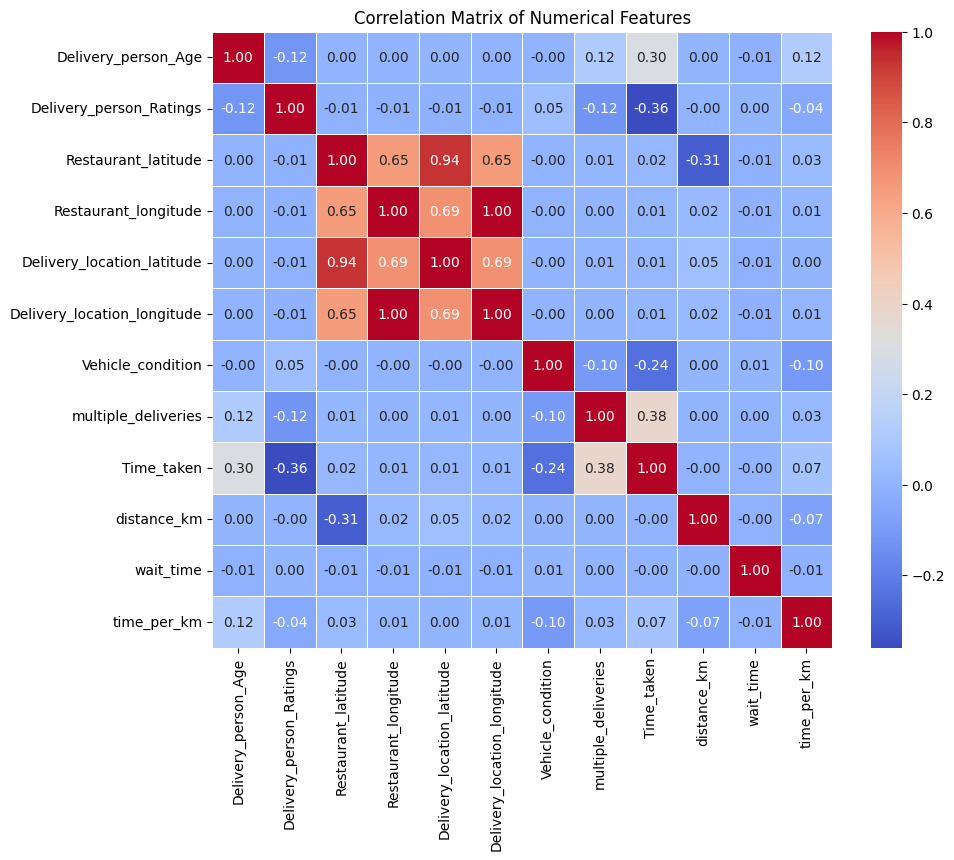

In [240]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [241]:
tb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43853 entries, 0 to 45583
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           43853 non-null  object        
 1   Delivery_person_ID           43853 non-null  object        
 2   Delivery_person_Age          43853 non-null  float64       
 3   Delivery_person_Ratings      43853 non-null  float64       
 4   Restaurant_latitude          43853 non-null  float64       
 5   Restaurant_longitude         43853 non-null  float64       
 6   Delivery_location_latitude   43853 non-null  float64       
 7   Delivery_location_longitude  43853 non-null  float64       
 8   Order_Date                   43853 non-null  object        
 9   Time_Orderd                  43853 non-null  object        
 10  Time_Order_picked            43853 non-null  object        
 11  Weather_conditions           43853 non-null  o

## Delivery Agent Profile Analysis

,Delivery_person_Age
count,43853.000000
mean,29.556952
std,5.747386
min,20.000000
25%,25.000000
50%,30.000000
75%,35.000000
max,39.000000


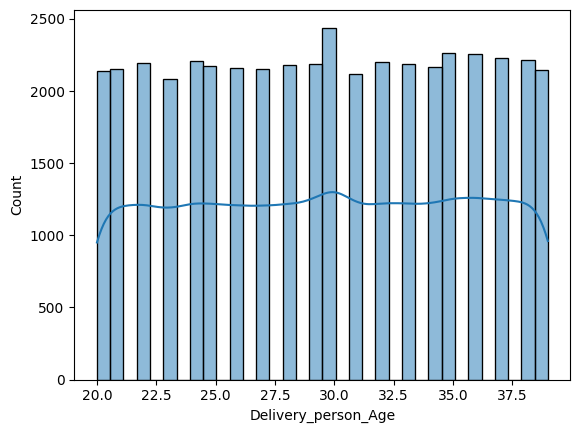

In [242]:
# Univariate Analysis
sns.histplot(tb['Delivery_person_Age'],kde=1)

tb['Delivery_person_Age'].describe()

,Delivery_person_Ratings
count,43853.000000
mean,4.635676
std,0.312931
min,2.500000
25%,4.500000
50%,4.700000
75%,4.900000
max,5.000000


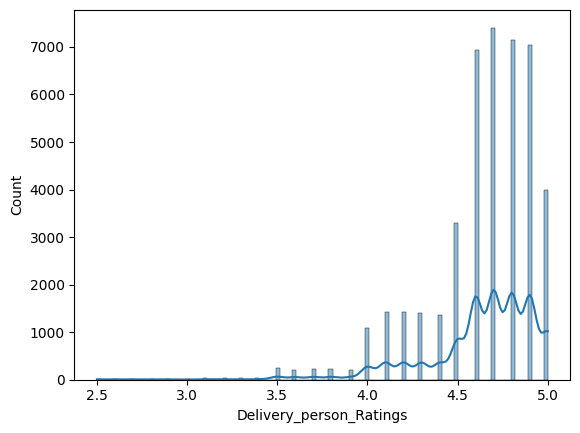

In [243]:
sns.histplot(tb['Delivery_person_Ratings'],kde=1)
tb['Delivery_person_Ratings'].describe()

<Axes: xlabel='Type_of_vehicle', ylabel='Count'>

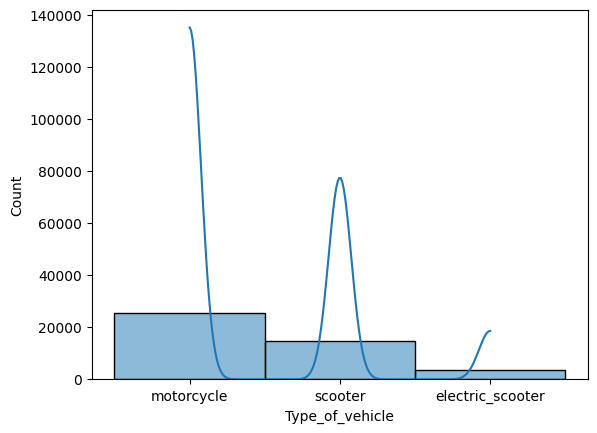

In [244]:


sns.histplot(tb['Type_of_vehicle'],kde=1)

In [245]:
tb['Type_of_vehicle'].describe()

,Type_of_vehicle
count,43853
unique,3
top,motorcycle
freq,25627


,multiple_deliveries
multiple_deliveries,
0.0,13587
1.0,28003
2.0,1920
3.0,343


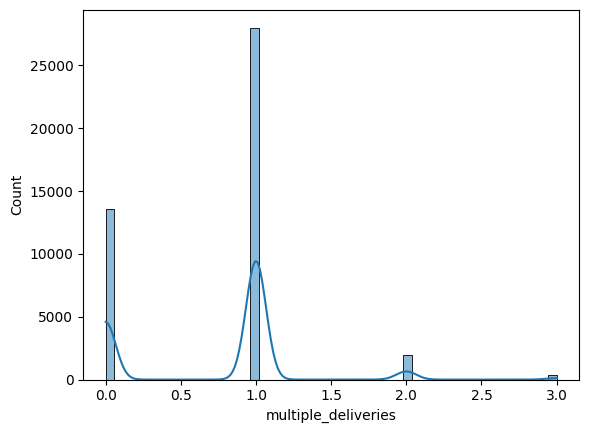

In [246]:
sns.histplot(tb['multiple_deliveries'],kde=1)
tb.groupby('multiple_deliveries')['multiple_deliveries'].count()

,Vehicle_condition
Vehicle_condition,
0,14599
1,14615
2,14639


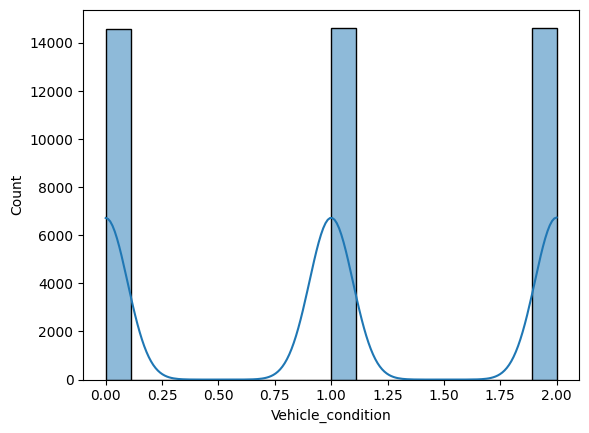

In [247]:
sns.histplot(tb['Vehicle_condition'],kde=1)
tb.groupby('Vehicle_condition')['Vehicle_condition'].count()

In [248]:
'Delivery_person_Age', 'Delivery_person_Ratings', 'Type_of_vehicle','multiple_deliveries','Vehicle_condition','Time_taken'

('Delivery_person_Age',
 'Delivery_person_Ratings',
 'Type_of_vehicle',
 'multiple_deliveries',
 'Vehicle_condition',
 'Time_taken')

,Time_taken
count,43853.000000
mean,26.293161
std,9.374274
min,10.000000
25%,19.000000
50%,26.000000
75%,32.000000
max,54.000000


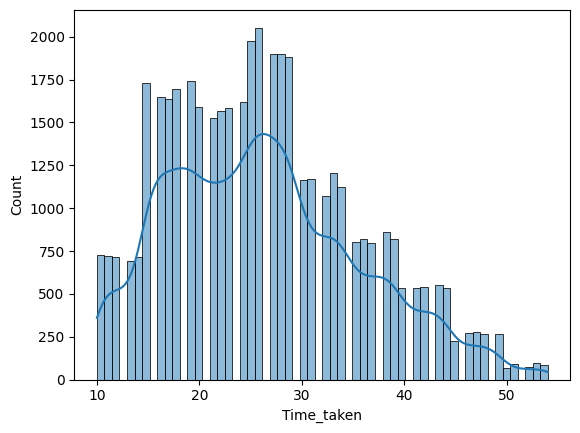

In [249]:
sns.histplot(tb['Time_taken'],kde=1)
tb['Time_taken'].describe()

In [250]:
TARGET='Time_taken'
 #These are your categorical columns to test one at a time
categorical_cols = [
    "Weather_conditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City"
]

/tmp/ipykernel_2359/3235679505.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tb,


                      median  mean  count
Road_traffic_density                     
High                    27.0  27.2   4320
Jam                     31.0  31.2  13796
Low                     20.0  21.3  15061
Medium                  27.0  26.7  10676


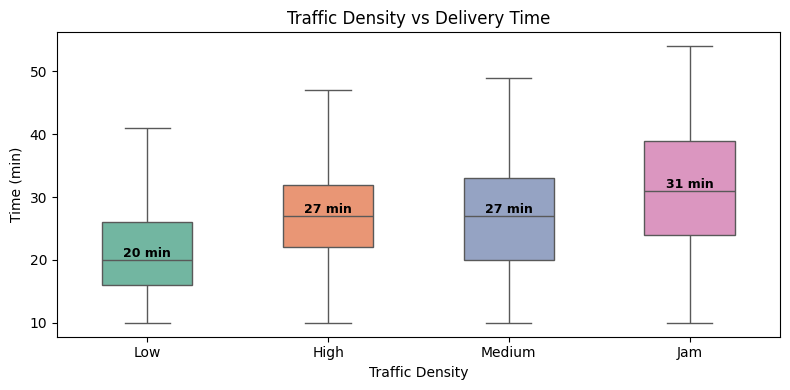

In [251]:
fig, ax = plt.subplots(figsize=(8, 4))

# Step 1: Sort by median so the chart tells a story (low → high)
order = (tb.groupby("Road_traffic_density")[TARGET]
           .median()
           .sort_values()
           .index.tolist())

# Step 2: Draw the boxplot
sns.boxplot(data=tb,
            x="Road_traffic_density",
            y=TARGET,
            order=order,
            palette="Set2",
            showfliers=False,   # hides extreme outliers so boxes are readable
            width=0.5,
            ax=ax)

# Step 3: Annotate median on each box — so the number is visible
for i, grp in enumerate(order):
    med = tb[tb["Road_traffic_density"] == grp][TARGET].median()
    ax.text(i, med + 0.4, f"{med:.0f} min",
            ha="center", fontsize=9, fontweight="bold")

# Step 4: Always print the numbers too — don't just trust the visual
print(tb.groupby("Road_traffic_density")[TARGET]
        .agg(["median", "mean", "count"])
        .round(1))

ax.set_title("Traffic Density vs Delivery Time")
ax.set_xlabel("Traffic Density")
ax.set_ylabel("Time (min)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2359/1511415037.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp, x=col, y=TARGET,
/tmp/ipykernel_2359/1511415037.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp, x=col, y=TARGET,
/tmp/ipykernel_2359/1511415037.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp, x=col, y=TARGET,
/tmp/ipykernel_2359/1511415037.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same

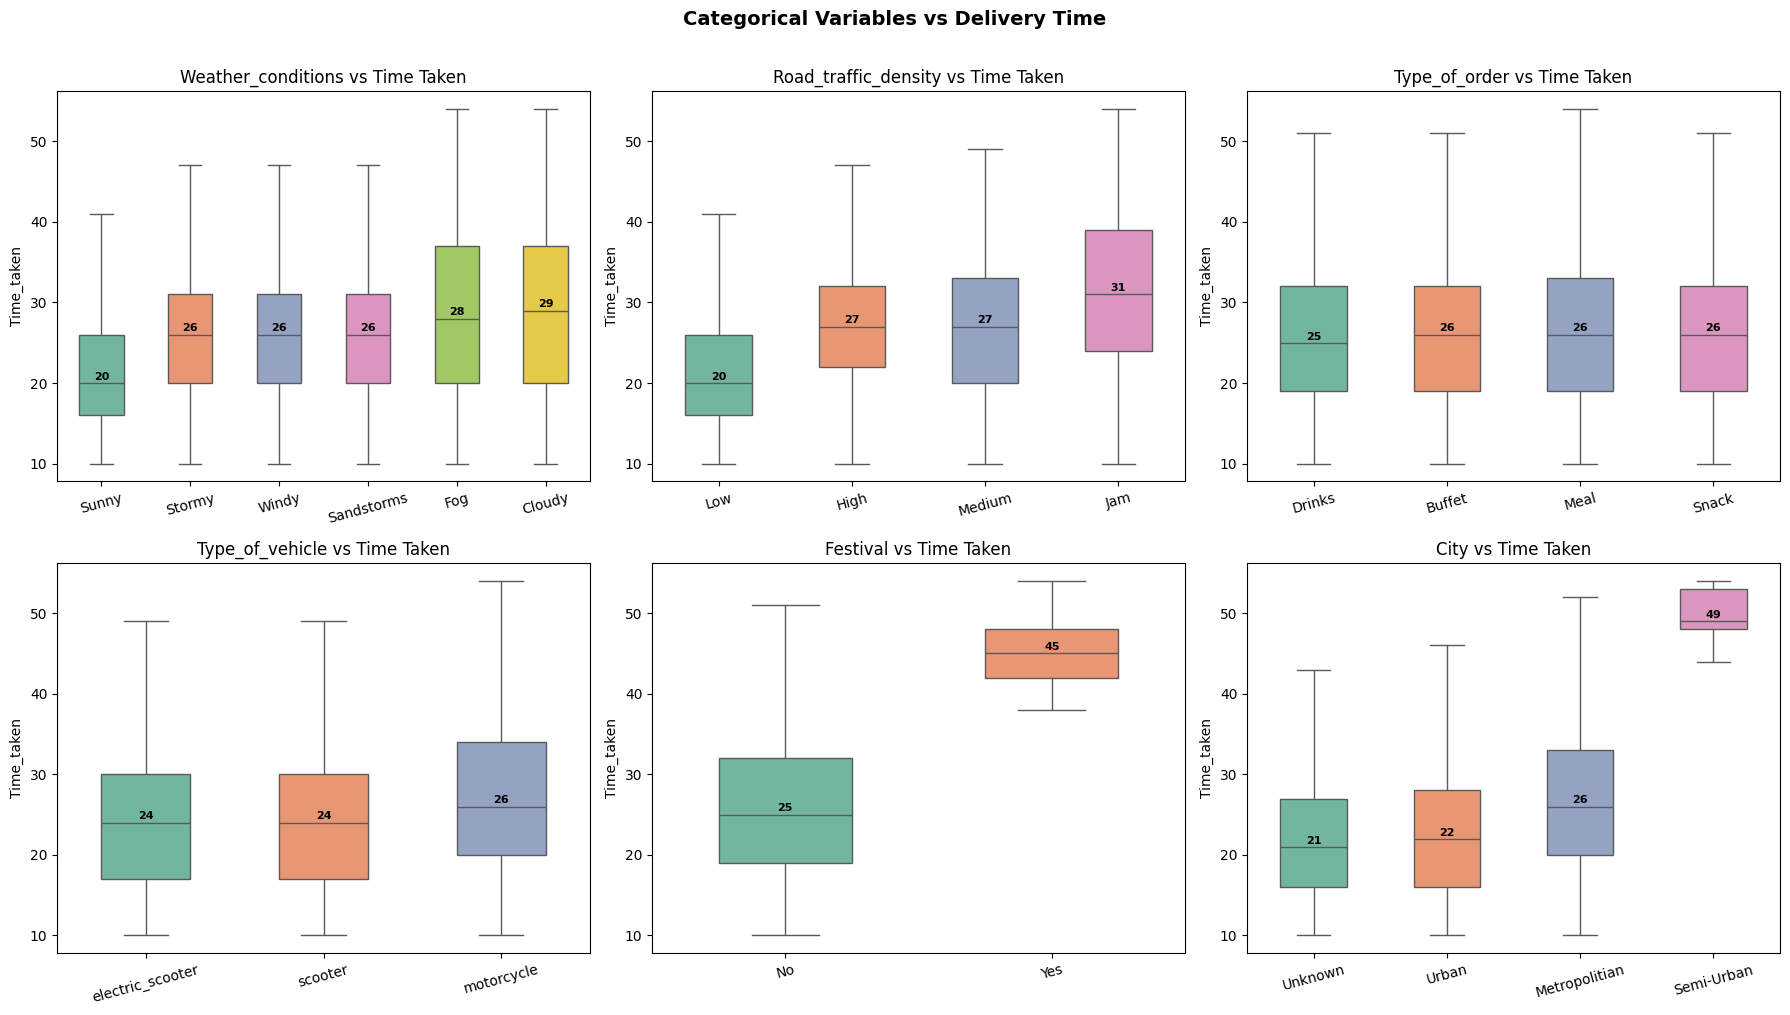

In [252]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]

    # Drop nulls just for this column
    temp = tb[[col, TARGET]].dropna()

    # Sort by median
    order = (temp.groupby(col)[TARGET]
                 .median()
                 .sort_values()
                 .index.tolist())

    sns.boxplot(data=temp, x=col, y=TARGET,
                order=order, palette="Set2",
                showfliers=False, width=0.5, ax=ax)

    # Annotate medians
    for j, grp in enumerate(order):
        med = temp[temp[col] == grp][TARGET].median()
        ax.text(j, med + 0.4, f"{med:.0f}",
                ha="center", fontsize=8, fontweight="bold")

    ax.set_title(f"{col} vs Time Taken")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=15)

plt.suptitle("Categorical Variables vs Delivery Time",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("categorical_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

## Hypothesis-1
Hypothesis testing for Weather Conditions Impact on Delivery Time under differengt road Traffic density

In [253]:
# Sunny condition median Time_taken=20mins, 6 mins less than the actual median. Is this driver or cofound?

# Control for traffic — does weather still matter?
# Filter to only JAM traffic, then check weather
jam_df = tb[tb["Road_traffic_density"] == "Jam"]
print(jam_df.groupby("Weather_conditions")["Time_taken"].median().sort_values())

# If medians are all similar within Jam → weather adds nothing beyond traffic

Weather_conditions
Sunny         21.0
Stormy        29.0
Windy         29.0
Sandstorms    29.0
Cloudy        37.0
Fog           37.0
Name: Time_taken, dtype: float64


In [254]:
# How many rows are in each bucket?
jam_df = tb[tb["Road_traffic_density"] == "Jam"]
print(jam_df.groupby("Weather_conditions")["Time_taken"]
      .agg(["median", "count"]).sort_values("median"))

                    median  count
Weather_conditions               
Sunny                 21.0   2241
Stormy                29.0   2264
Windy                 29.0   2296
Sandstorms            29.0   2331
Cloudy                37.0   2288
Fog                   37.0   2376


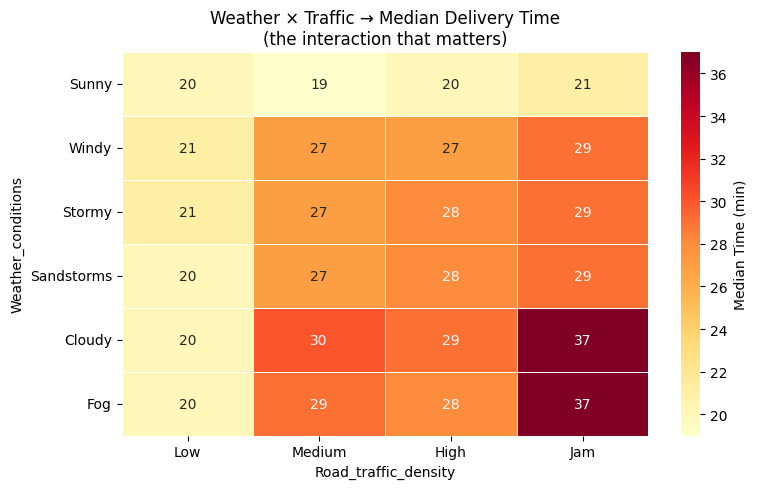

In [255]:
# The heatmap that tells the full story
pivot = tb.pivot_table(
    index="Weather_conditions",
    columns="Road_traffic_density",
    values="Time_taken",
    aggfunc="median"
)

# Order weather by severity
weather_order = ["Sunny", "Windy", "Stormy", "Sandstorms", "Cloudy", "Fog"]
traffic_order = ["Low", "Medium", "High", "Jam"]

pivot = pivot.reindex(index=weather_order, columns=traffic_order)

import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, ax=ax,
            cbar_kws={"label": "Median Time (min)"})
ax.set_title("Weather × Traffic → Median Delivery Time\n(the interaction that matters)")
plt.tight_layout()
plt.show()

Weather is not an independent predictor of delivery time in general — but within high-traffic (Jam) conditions, low-visibility weather (Fog, Cloudy) adds a significant 16-minute penalty over clear conditions. This interaction effect is consistent across balanced sample sizes and is a genuine finding

## Hypothesis Testing 2
As per the box-plot the time taken within Semi-Urban region is particularly high. Is this statistically significaant?

In [256]:
# Is Semi-Urban actually well-represented or is it a small sample?
print(tb["City"].value_counts())

# Is Sunny weather paired with Low traffic disproportionately?
# That would explain the 20 min median — it's a confound
print(pd.crosstab(tb["Weather_conditions"], tb["Road_traffic_density"], normalize="index").round(2))

City
Metropolitian    32796
Urban             9757
Unknown           1144
Semi-Urban         156
Name: count, dtype: int64
Road_traffic_density  High   Jam   Low  Medium
Weather_conditions                            
Cloudy                0.10  0.31  0.35    0.24
Fog                   0.10  0.32  0.34    0.24
Sandstorms            0.09  0.32  0.35    0.24
Stormy                0.10  0.31  0.36    0.24
Sunny                 0.10  0.32  0.34    0.24
Windy                 0.10  0.32  0.33    0.25


By checking the Cross-Tab It is evident that Weather conditions do not Impact the Traffic pattern- Indicating both are Independent Variables

The Semi-Urban data points is <0.1% not statistically Significant to make any type of etimates.

Road_traffic_density  High   Jam   Low  Medium
Festival                                      
No                    27.0  30.0  20.0    26.0
Yes                   46.0  46.0  42.0    44.0


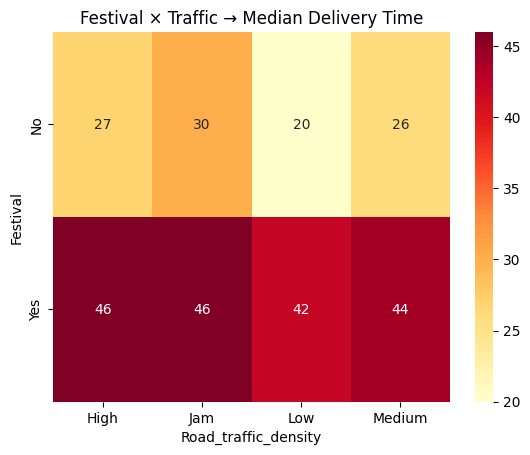

In [257]:
# Does traffic density hit harder during festivals?
pivot = tb.pivot_table(
    index="Festival",
    columns="Road_traffic_density",
    values="Time_taken",
    aggfunc="median"
)
print(pivot)

import seaborn as sns
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Festival × Traffic → Median Delivery Time")
plt.show()

In [258]:
tb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43853 entries, 0 to 45583
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           43853 non-null  object        
 1   Delivery_person_ID           43853 non-null  object        
 2   Delivery_person_Age          43853 non-null  float64       
 3   Delivery_person_Ratings      43853 non-null  float64       
 4   Restaurant_latitude          43853 non-null  float64       
 5   Restaurant_longitude         43853 non-null  float64       
 6   Delivery_location_latitude   43853 non-null  float64       
 7   Delivery_location_longitude  43853 non-null  float64       
 8   Order_Date                   43853 non-null  object        
 9   Time_Orderd                  43853 non-null  object        
 10  Time_Order_picked            43853 non-null  object        
 11  Weather_conditions           43853 non-null  o


Correlation with Time_taken:
             distance_km  Time_taken
distance_km        1.000      -0.002
Time_taken        -0.002       1.000


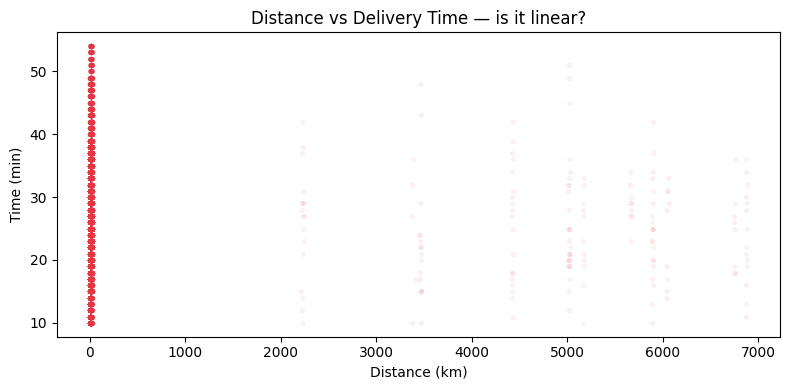

In [260]:
# Step 2: Correlation
print("\nCorrelation with Time_taken:")
print(tb[["distance_km", "Time_taken"]].corr().round(3))

# Step 3: Scatter plot
plt.figure(figsize=(8, 4))
plt.scatter(tb["distance_km"], tb["Time_taken"],
            alpha=0.05, s=8, color="#E23744")
plt.xlabel("Distance (km)")
plt.ylabel("Time (min)")
plt.title("Distance vs Delivery Time — is it linear?")
plt.tight_layout()
plt.show()

Delivery time at Zomato is primarily driven by road congestion, not distance. Traffic density alone explains a baseline difference of 11 minutes (Low: 20 min vs Jam: 31 min). However, the critical insight is that weather acts as a multiplier on congestion — not independently. Under Low traffic, all weather conditions produce identical delivery times (~20 min). Under Jam conditions, low-visibility weather (Fog, Cloudy) pushes median delivery time to 37 minutes — an 85% increase over baseline. Distance shows near-zero correlation (r = -0.002), confirming that operational conditions, not geography, determine delivery performance."

In [261]:
## Wait_time Analysis
print(tb["wait_time"].describe().round(2))
print("\nCorrelation with delivery time:",
      tb[["wait_time", "Time_taken"]].corr().round(3))

count    35407.00
mean         9.94
std          4.09
min          5.00
25%          5.00
50%         10.00
75%         15.00
max         15.00
Name: wait_time, dtype: float64

Correlation with delivery time:             wait_time  Time_taken
wait_time       1.000      -0.002
Time_taken     -0.002       1.000


<Axes: xlabel='wait_time', ylabel='Count'>

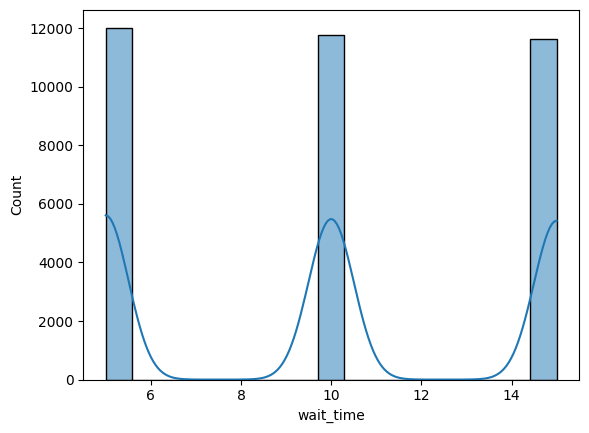

In [262]:
sns.histplot(tb["wait_time"],kde=1)